In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Prediction based on values close by (we did this before)

In [34]:
family_heights = Table.read_table('data/family_heights.csv')
family_heights

family,father,mother,midparentHeight,children,childNum,sex,childHeight
1,78.5,67,75.43,4,1,male,73.2
1,78.5,67,75.43,4,2,female,69.2
1,78.5,67,75.43,4,3,female,69
1,78.5,67,75.43,4,4,female,69
2,75.5,66.5,73.66,4,1,male,73.5
2,75.5,66.5,73.66,4,2,male,72.5
2,75.5,66.5,73.66,4,3,female,65.5
2,75.5,66.5,73.66,4,4,female,65.5
3,75,64,72.06,2,1,male,71
3,75,64,72.06,2,2,female,68


In [35]:
heights = family_heights.relabeled(['midparentHeight', 'childHeight'], ['MidParent', 'Child']).select('MidParent', 'Child')
heights

MidParent,Child
75.43,73.2
75.43,69.2
75.43,69
75.43,69
73.66,73.5
73.66,72.5
73.66,65.5
73.66,65.5
72.06,71
72.06,68


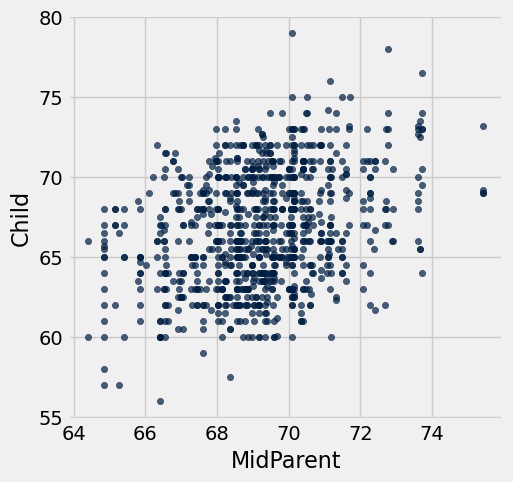

In [5]:
heights.scatter('MidParent')

In [6]:
def predict_height(mp_height):
    close_points = heights.where('MidParent', are.between(mp_height - 0.5, mp_height + 0.5))
    return close_points.column('Child').mean()

In [7]:
predict_height(71)

67.740594059405936

In [9]:
heights

MidParent,Child
75.43,73.2
75.43,69.2
75.43,69
75.43,69
73.66,73.5
73.66,72.5
73.66,65.5
73.66,65.5
72.06,71
72.06,68


In [11]:
heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_height, 'MidParent')
)
heights_with_predictions

MidParent,Child,Prediction
75.43,73.2,70.1
75.43,69.2,70.1
75.43,69,70.1
75.43,69,70.1
73.66,73.5,70.4158
73.66,72.5,70.4158
73.66,65.5,70.4158
73.66,65.5,70.4158
72.06,71,68.5025
72.06,68,68.5025


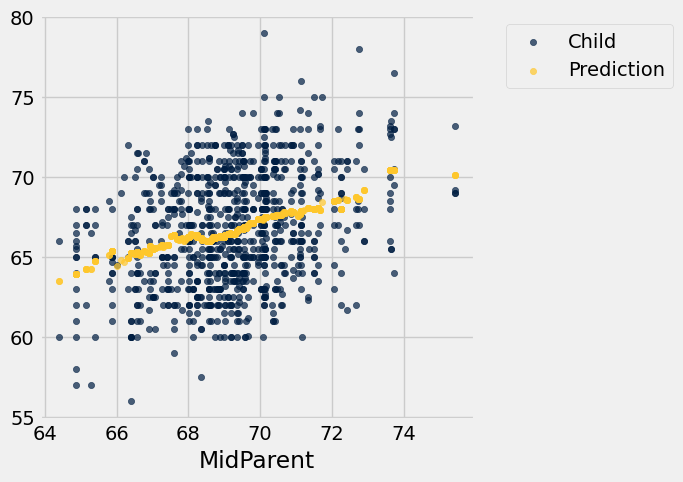

In [12]:
heights_with_predictions.scatter('MidParent')

# Correlation

In [13]:
# don't worry about this code
def r_scatter(r):
    'Generate a scatter plot with a correlation approximately r'
    plt.figure(figsize=(5,5))
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plt.scatter(x, y)
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)

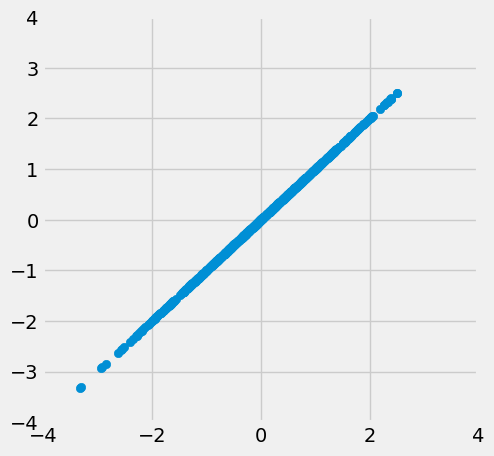

In [14]:
r_scatter(1)

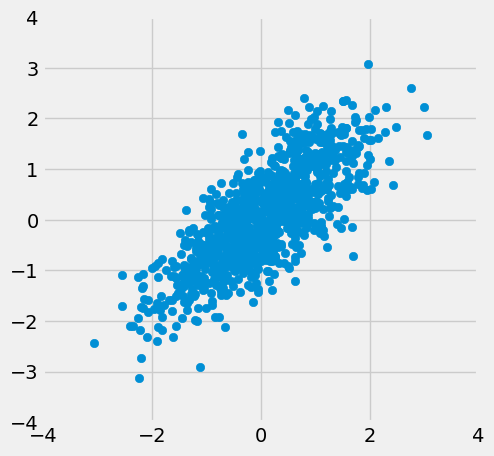

In [15]:
r_scatter(0.8)

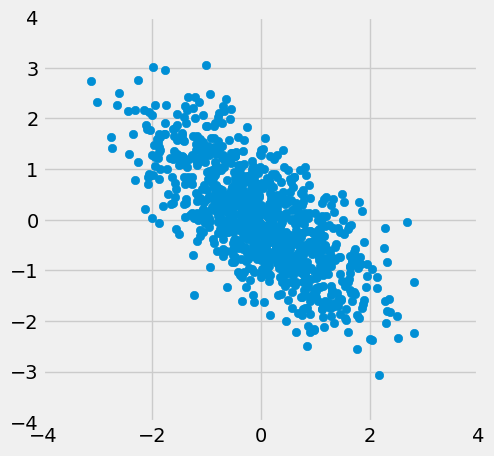

In [16]:
r_scatter(-0.7)

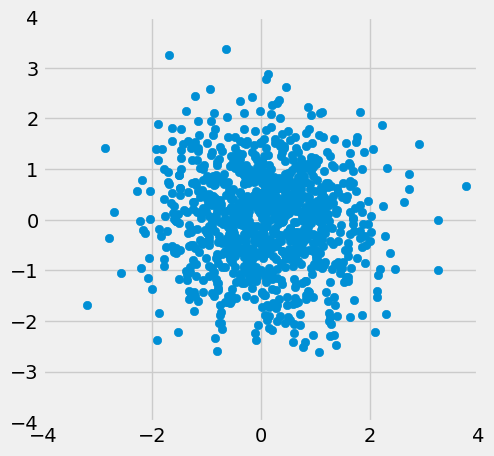

In [17]:
r_scatter(0)

In [19]:
hybrid = Table.read_table('data/hybrid.csv')
hybrid.sample()

vehicle,year,msrp,acceleration,mpg,class
Cadillac Escalade,2008,78932.8,9.09,22.35,SUV
LaCrosse,2012,30049.5,11.36,29,Midsize
MKZ FWD,2011,34748.5,11.49,39,Midsize
Lexus RX450h,2009,46233.4,13.47,31.99,SUV
Insight,2012,18555.3,9.42,42,Compact
Insight,2010,19859.2,9.17,41,Compact
LaCrosse,2013,31660,11.36,29,Midsize
Tino,2000,35355,8.2,54.1,Compact
Malibu,2009,24768.8,9.09,29,Midsize
Fuga Infiniti M35H,2010,70157,18.65,33.64,Midsize


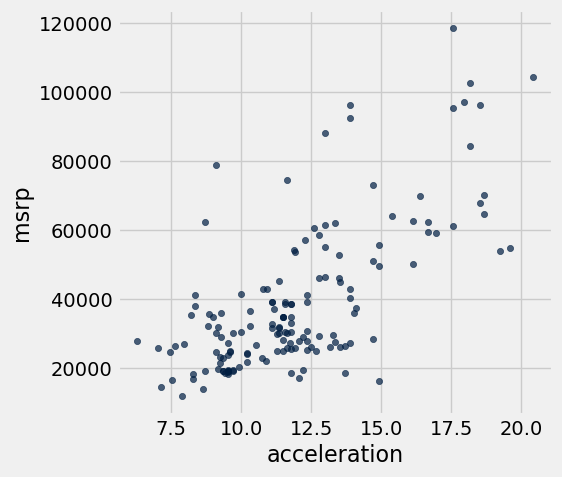

In [20]:
# Crushed ICE: make some scatter plots and see if two variables correlate with each other
hybrid.scatter('acceleration', 'msrp')

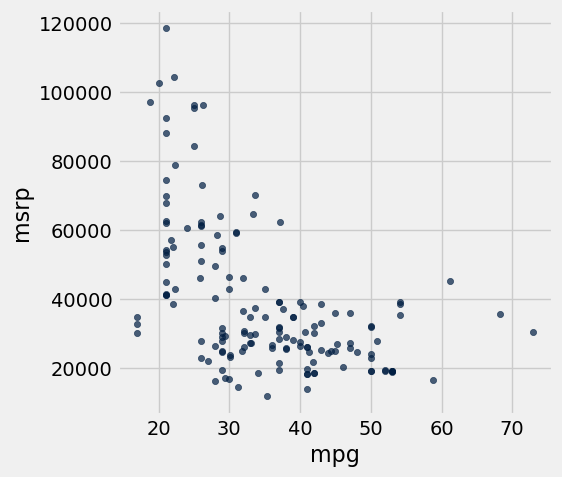

In [22]:
hybrid.scatter('mpg', 'msrp')

In [23]:
# ^ not linear!

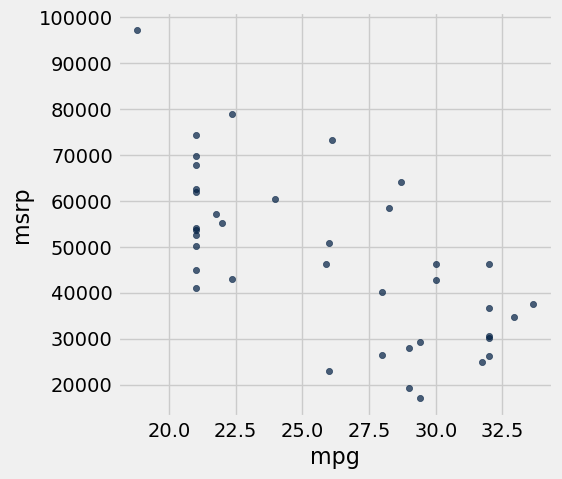

In [24]:
suv = hybrid.where('class', 'SUV')
suv.scatter('mpg', 'msrp')

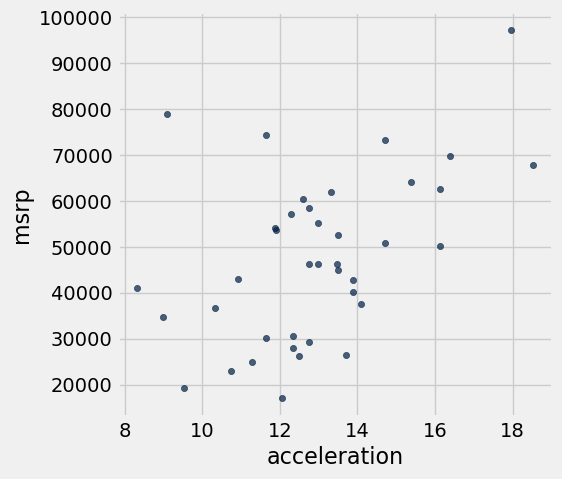

In [25]:
suv.scatter('acceleration', 'msrp')

In [2]:
def standard_units(numbers_array):
    return (numbers_array - np.mean(numbers_array)) / np.std(numbers_array)

In [28]:
suv.column('mpg')

array([ 31.99,  28.23,  29.4 ,  29.  ,  32.93,  22.35,  25.87,  31.75,
        21.78,  26.  ,  22.35,  31.99,  23.99,  18.82,  28.  ,  21.  ,
        21.  ,  28.7 ,  33.64,  29.4 ,  26.11,  29.  ,  32.  ,  30.  ,
        22.  ,  32.  ,  32.  ,  21.  ,  21.  ,  21.  ,  30.  ,  28.  ,
        26.  ,  21.  ,  21.  ,  21.  ,  21.  ,  21.  ,  21.  ])

In [29]:
standard_units(suv.column('mpg'))

array([ 1.31783623,  0.48954981,  0.74728787,  0.6591723 ,  1.52490784,
       -0.80574917, -0.03033209,  1.26496689, -0.93131387, -0.00169453,
       -0.80574917,  1.31783623, -0.4444753 , -1.58336914,  0.43888335,
       -1.10313924, -1.10313924,  0.59308561,  1.68131299,  0.74728787,
        0.02253725,  0.6591723 ,  1.32003912,  0.87946124, -0.8828503 ,
        1.32003912,  1.32003912, -1.10313924, -1.10313924, -1.10313924,
        0.87946124,  0.43888335, -0.00169453, -1.10313924, -1.10313924,
       -1.10313924, -1.10313924, -1.10313924, -1.10313924])

In [31]:
suv2 = suv.select('mpg', 'msrp', 'acceleration').with_columns(
    'mpg (standard units)', standard_units(suv.column('mpg')),
    'msrp (standard units)', standard_units(suv.column('msrp')),
    'acceleration (standard units)', standard_units(suv.column('acceleration'))
)
suv2

mpg,msrp,acceleration,mpg (standard units),msrp (standard units),acceleration (standard units)
31.99,36676.1,10.32,1.31784,-0.60884,-1.16157
28.23,58521.1,12.76,0.48955,0.605991,-0.0718039
29.4,29186.2,12.76,0.747288,-1.02536,-0.0718039
29,19322.6,9.52,0.659172,-1.57389,-1.51888
32.93,34772.4,8.98,1.52491,-0.714707,-1.76005
22.35,42924.3,10.91,-0.805749,-0.261367,-0.898064
25.87,46229.5,12.76,-0.0303321,-0.0775641,-0.0718039
31.75,24823.8,11.28,1.26497,-1.26796,-0.732812
21.78,57094.8,12.28,-0.931314,0.526671,-0.286185
26,22938.3,10.75,-0.00169453,-1.37281,-0.969524


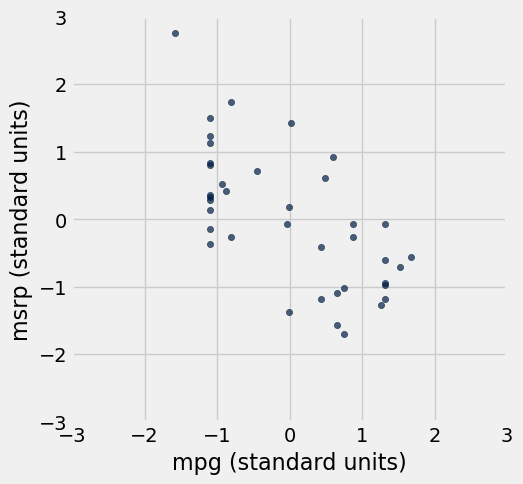

In [33]:
suv2.scatter(3, 4)
plt.xlim(-3, 3)
plt.ylim(-3, 3);

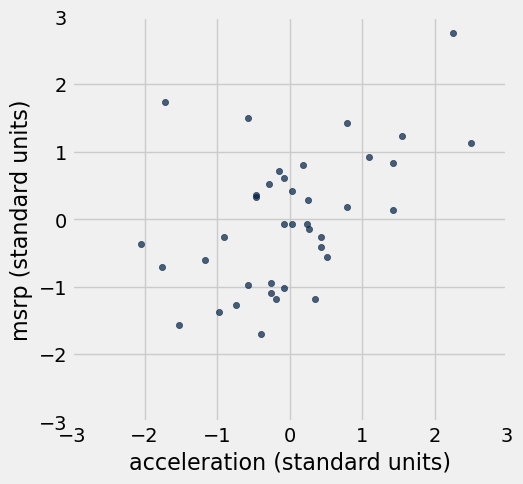

In [34]:
suv2.scatter(5, 4)
plt.xlim(-3, 3)
plt.ylim(-3, 3);

# Calculating r

In [35]:
x = np.arange(1, 7, 1)
y = make_array(2, 3, 1, 5, 2, 7)
t = Table().with_columns(
    'x', x,
    'y', y
)
t

x,y
1,2
2,3
3,1
4,5
5,2
6,7


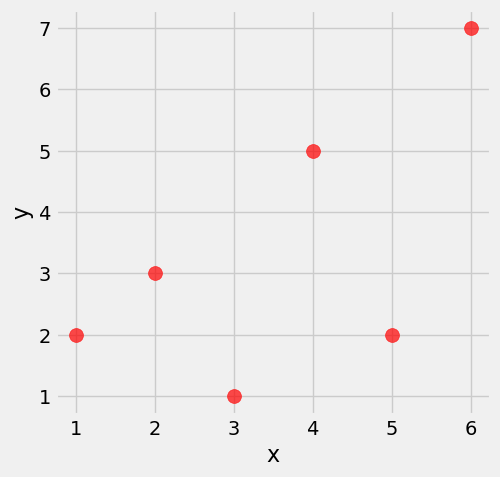

In [36]:
t.scatter('x', 'y', s=100, color='red')

In [37]:
t

x,y
1,2
2,3
3,1
4,5
5,2
6,7


In [38]:
t_su = t.with_columns(
    'x (standard units)', standard_units(x),
    'y (standard units)', standard_units(y)
)
t_su

x,y,x (standard units),y (standard units)
1,2,-1.46385,-0.648886
2,3,-0.87831,-0.162221
3,1,-0.29277,-1.13555
4,5,0.29277,0.811107
5,2,0.87831,-0.648886
6,7,1.46385,1.78444


In [42]:
t_product = t_su.with_column('product of standard units', t_su.column(2) * t_su.column(3))
t_product

x,y,x (standard units),y (standard units),product of standard units
1,2,-1.46385,-0.648886,0.949871
2,3,-0.87831,-0.162221,0.142481
3,1,-0.29277,-1.13555,0.332455
4,5,0.29277,0.811107,0.237468
5,2,0.87831,-0.648886,-0.569923
6,7,1.46385,1.78444,2.61215


In [43]:
r = np.mean(t_product.column(4))
r

0.61741639718977093

In [3]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))

In [45]:
correlation(t, 'x', 'y')

0.61741639718977093

In [46]:
correlation(suv, 'mpg', 'msrp')

-0.6667143635709919

In [47]:
correlation(suv, 'acceleration', 'msrp')

0.48699799279959155

In [48]:
correlation(suv, 'msrp', 'acceleration')

0.48699799279959155

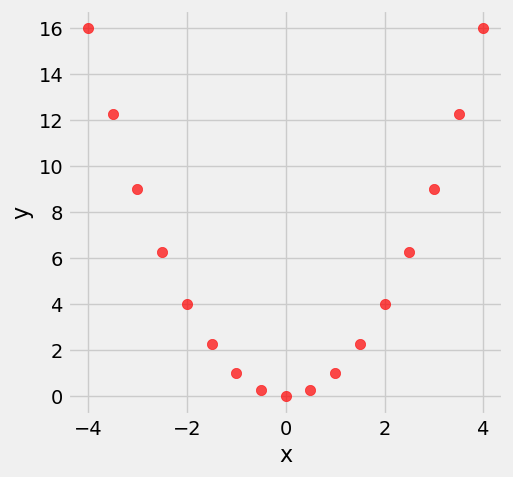

In [50]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = Table().with_columns(
    'x', new_x,
    'y', new_x**2
)
nonlinear.scatter('x', 'y', s=55, color='r')

In [51]:
correlation(nonlinear, 'x', 'y')

0.0

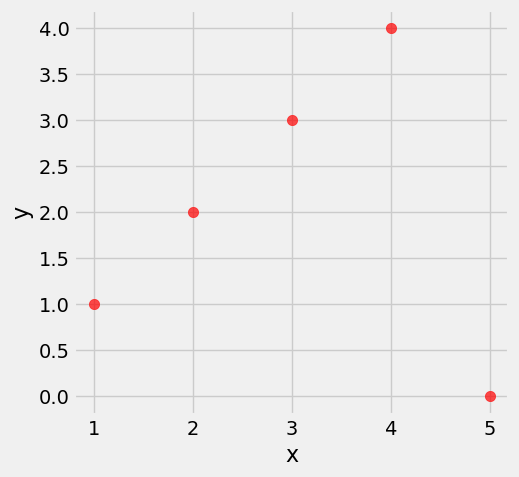

In [52]:
outlier = Table().with_columns(
    'x', make_array(1, 2, 3, 4, 5),
    'y', make_array(1, 2, 3, 4, 0)
)
outlier.scatter('x', 'y', s=55, color='r')

In [53]:
correlation(outlier, 'x', 'y')

0.0

In [54]:
correlation(outlier.where('x', are.below(5)), 'x', 'y')

1.0

# Crushed ICE Examples

In [55]:
sons_heights = Table.read_table('data/sons_heights.csv')
sons_heights

father,mother,son
78.5,67,73.2
75.5,66.5,73.5
75,64,71
75,64,70.5
75,58.5,72
74,68,76.5
74,62,74
73,67,71
73,67,68
73,66.5,71


0.50072475554943707

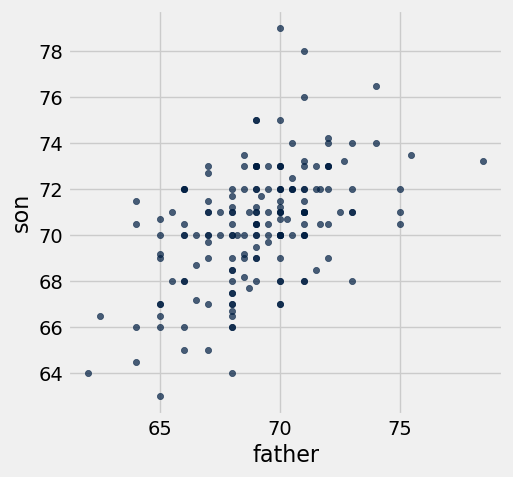

In [60]:
sons_heights.scatter('father', 'son')
correlation(sons_heights, 'father', 'son')

In [66]:
father_heights = sons_heights.column('father')
father_su = (father_heights - np.mean(father_heights)) / np.std(father_heights)
son_su = standard_units(sons_heights.column('son'))
np.mean(father_su * son_su)

0.50072475554943707

---

In [4]:
cereal = Table.read_table('data/cereal.csv')
cereal

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138


In [7]:
def standard_units(numbers_array):
    return (numbers_array - np.mean(numbers_array)) / np.std(numbers_array)

In [6]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))

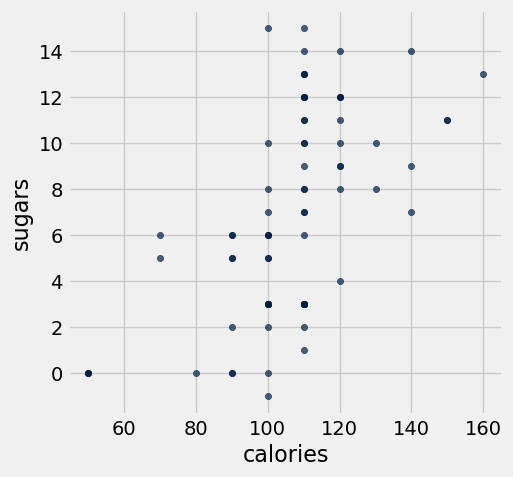

In [8]:
cereal.scatter('calories', 'sugars')

In [7]:
correlation(cereal, 'calories', 'sugars')

0.56234028980348827

In [9]:
correlation(cereal, 'fiber', 'potass')

0.90337366859420387

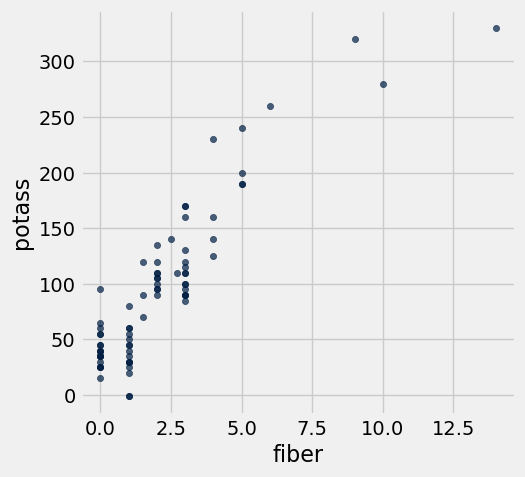

In [10]:
cereal.scatter('fiber', 'potass')

In [12]:
correlation(cereal, 'sodium', 'potass')

-0.032603466939581938

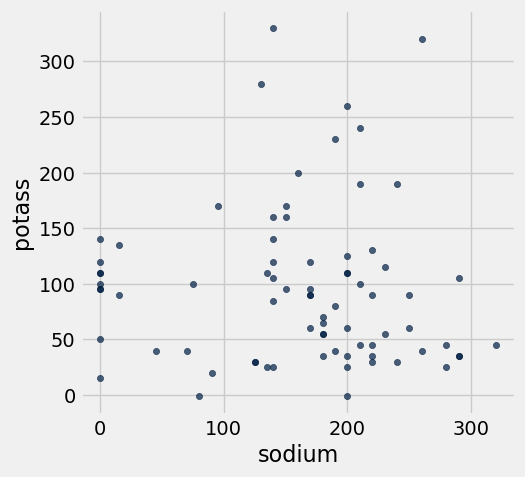

In [11]:
cereal.scatter('sodium', 'potass')

In [14]:
correlation(cereal, 'fiber', 'calories')

-0.2934127517983216

In [15]:
for a in make_array(1, 2, 3):
    for b in make_array('x', 'y', 'z'):
        print(a, b)

1 x
1 y
1 z
2 x
2 y
2 z
3 x
3 y
3 z


In [16]:
pokemon = Table.read_table('data/pokemon.csv')
pokemon

abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13,1,0
"['Overgrow', 'Chlorophyll']",1,1,1,0.5,0.5,0.5,2,2,1,0.25,1,2,1,1,2,1,1,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,nan,8.5,1,0
"['Blaze', 'Solar Power']",0.5,1,1,1,0.5,1,0.5,1,1,0.5,2,0.5,1,1,1,2,0.5,2,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,nan,19,1,0
"['Blaze', 'Solar Power']",0.25,1,1,2,0.5,0.5,0.5,1,1,0.25,0,1,1,1,1,4,0.5,2,104,5120,70,634,45,Flame Pokémon,78,1059860,1.7,78,Lizardonリザードン,Charizard,88.1,6,159,115,100,fire,flying,90.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,48,5120,70,314,45,Tiny Turtle Pokémon,65,1059860,0.5,44,Zenigameゼニガメ,Squirtle,88.1,7,50,64,43,water,nan,9,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,63,5120,70,405,45,Turtle Pokémon,80,1059860,1,59,Kameilカメール,Wartortle,88.1,8,65,80,58,water,nan,22.5,1,0
"['Torrent', 'Rain Dish']",1,1,1,2,1,1,0.5,1,1,2,1,0.5,1,1,1,1,0.5,0.5,103,5120,70,630,45,Shellfish Pokémon,120,1059860,1.6,79,Kamexカメックス,Blastoise,88.1,9,135,115,78,water,nan,85.5,1,0
"['Shield Dust', 'Run Away']",1,1,1,1,1,0.5,2,2,1,0.5,0.5,1,1,1,1,2,1,1,30,3840,70,195,255,Worm Pokémon,35,1000000,0.3,45,Caterpieキャタピー,Caterpie,50,10,20,20,45,bug,nan,2.9,1,0


In [18]:
labels = make_array('attack', 'defense', 'hp', 'sp_attack', 'sp_defense', 'speed')

In [20]:
for x in labels:
    for y in labels:
        print(x, y, correlation(pokemon, x, y))

attack attack 1.0
attack defense 0.468914913919
attack hp 0.410615789307
attack sp_attack 0.36815399955
attack sp_defense 0.265836226129
attack speed 0.352702640037
defense attack 0.468914913919
defense defense 1.0
defense hp 0.242378155602
defense sp_attack 0.241882032833
defense sp_defense 0.526348275722
defense speed 0.00793406903265
hp attack 0.410615789307
hp defense 0.242378155602
hp hp 1.0
hp sp_attack 0.365972644656
hp sp_defense 0.366970744412
hp speed 0.160759818079
sp_attack attack 0.36815399955
sp_attack defense 0.241882032833
sp_attack hp 0.365972644656
sp_attack sp_attack 1.0
sp_attack sp_defense 0.511495507711
sp_attack speed 0.438981267713
sp_defense attack 0.265836226129
sp_defense defense 0.526348275722
sp_defense hp 0.366970744412
sp_defense sp_attack 0.511495507711
sp_defense sp_defense 1.0
sp_defense speed 0.225976980379
speed attack 0.352702640037
speed defense 0.00793406903265
speed hp 0.160759818079
speed sp_attack 0.438981267713
speed sp_defense 0.225976980379


In [22]:
Table(labels=['hi', 'mom']).append([1, 2]) # append modifies the table

hi,mom
1,2


In [25]:
correlations = Table(labels=['x', 'y', 'correlation'])

for x in labels:
    for y in labels:
        correlations.append([x, y, correlation(pokemon, x, y)])

correlations.sort('correlation').show()

x,y,correlation
defense,speed,0.00793407
speed,defense,0.00793407
hp,speed,0.16076
speed,hp,0.16076
sp_defense,speed,0.225977
speed,sp_defense,0.225977
defense,sp_attack,0.241882
sp_attack,defense,0.241882
defense,hp,0.242378
hp,defense,0.242378


# Don't misinterpret r

In [28]:
sat2014 = Table.read_table('data/sat2014.csv').sort('State')
sat2014

State,Participation Rate,Critical Reading,Math,Writing,Combined
Alabama,6.7,547,538,532,1617
Alaska,54.2,507,503,475,1485
Arizona,36.4,522,525,500,1547
Arkansas,4.2,573,571,554,1698
California,60.3,498,510,496,1504
Colorado,14.3,582,586,567,1735
Connecticut,88.4,507,510,508,1525
Delaware,100,456,459,444,1359
District of Columbia,100,440,438,431,1309
Florida,72.2,491,485,472,1448


In [29]:
# The data consist of average scores in each state

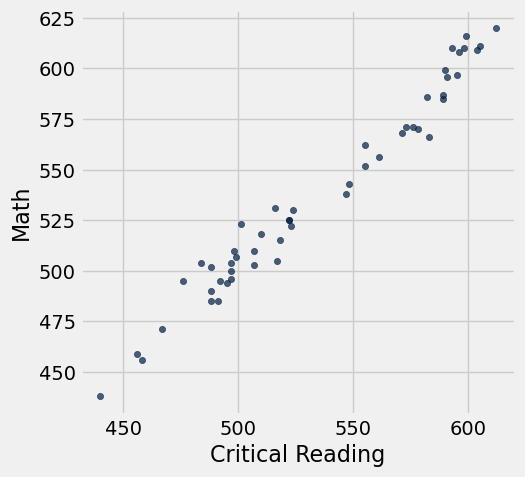

In [30]:
sat2014.scatter('Critical Reading', 'Math')

In [31]:
correlation(sat2014, 'Critical Reading', 'Math')

0.98475584110674341

In [32]:
# States don't take tests, students do!
# All the students have been lumped together, so all we can say is that there's a
# correlation between the average math/reading scores.
# This says nothing about individual students.
# We all know plenty of people who are good at one subject but not the other.

# The regression line

In [36]:
heights

MidParent,Child
75.43,73.2
75.43,69.2
75.43,69
75.43,69
73.66,73.5
73.66,72.5
73.66,65.5
73.66,65.5
72.06,71
72.06,68


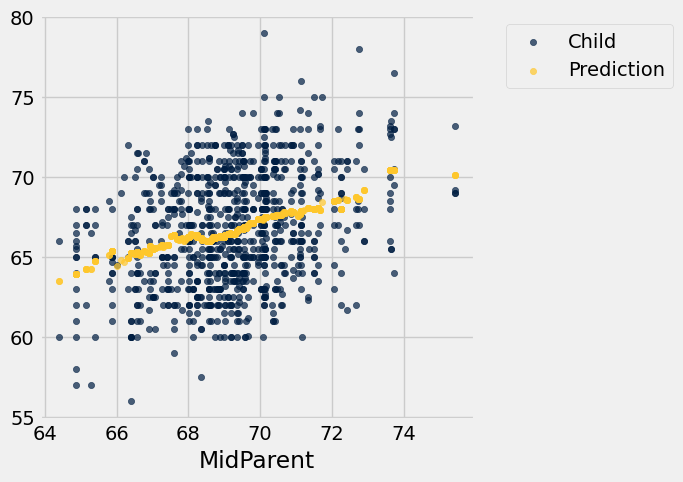

In [56]:
def predict_height(mp_height):
    close_points = heights.where('MidParent', are.between(mp_height - 0.5, mp_height + 0.5))
    return close_points.column('Child').mean()

heights_with_predictions = heights.with_column(
    'Prediction', heights.apply(predict_height, 'MidParent')
)

heights_with_predictions.scatter('MidParent')

In [38]:
# ^ we want to do something like this, but with a perfectly straight line

## Linear association doesn't depend on the units

In [41]:
def standard_units(numbers_array):
    return (numbers_array - np.mean(numbers_array)) / np.std(numbers_array)

heights_SU = Table().with_columns(
    'MidParent SU', standard_units(heights.column('MidParent')),
    'Child SU', standard_units(heights.column('Child'))
)

heights_SU

MidParent SU,Child SU
3.45465,1.80416
3.45465,0.686005
3.45465,0.630097
3.45465,0.630097
2.47209,1.88802
2.47209,1.60848
2.47209,-0.348285
2.47209,-0.348285
1.58389,1.18917
1.58389,0.350559


In [43]:
sd_midparent = np.std(heights.column('MidParent'))
sd_midparent

1.8014050969207571

In [44]:
0.5 / sd_midparent

0.27756111096536701

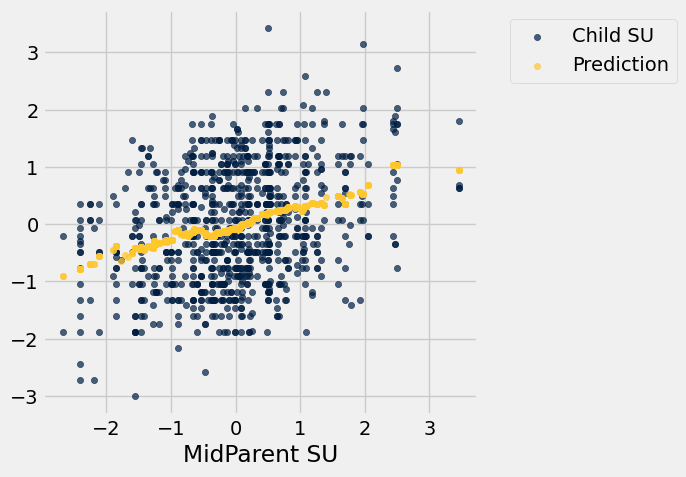

In [55]:
def predict_height_su(mp_height_su):
    close = 0.5 / sd_midparent
    close_points = heights_SU.where('MidParent SU', are.between(mp_height_su - close, mp_height_su + close))
    return close_points.column('Child SU').mean()

heights_with_su_predictions = heights_SU.with_column(
    'Prediction', heights_SU.apply(predict_height_su, 'MidParent SU')
)

heights_with_su_predictions.scatter('MidParent SU')

## Formulas for the regression line

In [5]:
def correlation(t, label_x, label_y):
    return np.mean(standard_units(t.column(label_x))*standard_units(t.column(label_y)))

def slope(t, label_x, label_y):
    r = correlation(t, label_x, label_y)
    return r*np.std(t.column(label_y))/np.std(t.column(label_x))

def intercept(t, label_x, label_y):
    return np.mean(t.column(label_y)) - slope(t, label_x, label_y)*np.mean(t.column(label_x))

In [51]:
family_r = correlation(heights, 'MidParent', 'Child')
family_r

0.32094989606395924

In [52]:
family_slope = slope(heights, 'MidParent', 'Child')
family_intercept = intercept(heights, 'MidParent', 'Child')
family_slope, family_intercept

(0.63736089696947895, 22.636240549589751)

In [53]:
family_slope * 70.48 + family_intercept

67.557436567998622

In [57]:
heights_with_predictions.where('MidParent', 70.48)

MidParent,Child,Prediction
70.48,74,67.6342
70.48,70,67.6342
70.48,68,67.6342
70.48,67,67.6342
70.48,67,67.6342
70.48,66,67.6342
70.48,63.5,67.6342
70.48,63,67.6342


In [59]:
heights_with_predictions2 = heights_with_predictions.with_column(
    'Regression Prediction', family_slope * heights.column('MidParent') + family_intercept
)
heights_with_predictions2

MidParent,Child,Prediction,Regression Prediction
75.43,73.2,70.1,70.7124
75.43,69.2,70.1,70.7124
75.43,69,70.1,70.7124
75.43,69,70.1,70.7124
73.66,73.5,70.4158,69.5842
73.66,72.5,70.4158,69.5842
73.66,65.5,70.4158,69.5842
73.66,65.5,70.4158,69.5842
72.06,71,68.5025,68.5645
72.06,68,68.5025,68.5645


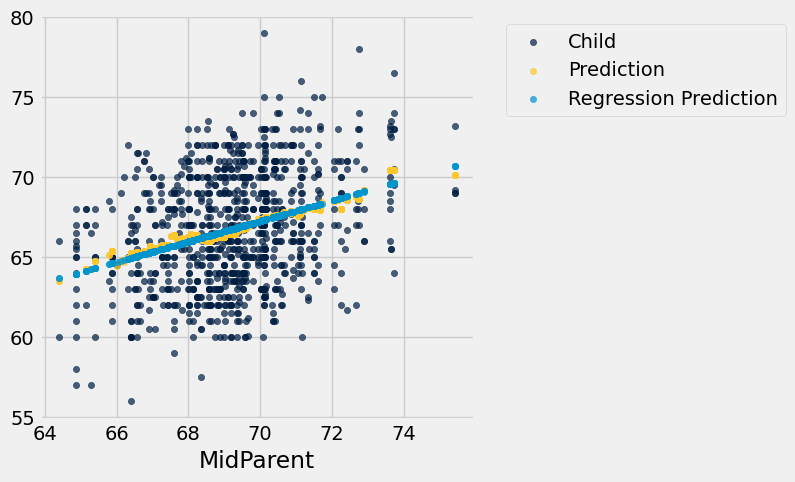

In [60]:
heights_with_predictions2.scatter('MidParent')

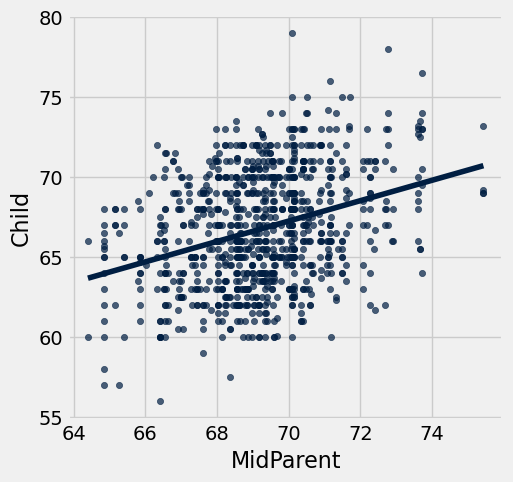

In [63]:
heights.scatter('MidParent', 'Child', fit_line=True)

## Error in estimation

In [66]:
baby = Table.read_table('data/baby.csv').select('Maternal Height', 'Maternal Pregnancy Weight')
baby

Maternal Height,Maternal Pregnancy Weight
62,100
64,135
64,115
67,125
62,93
62,178
65,140
62,125
66,136
68,120


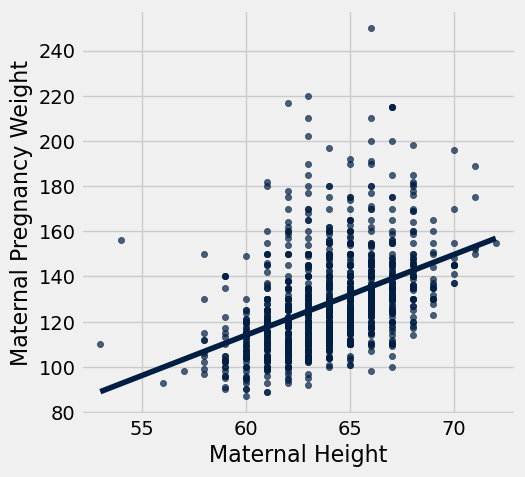

In [68]:
baby.scatter('Maternal Height', 'Maternal Pregnancy Weight', fit_line=True)

In [70]:
correlation(baby, 'Maternal Height', 'Maternal Pregnancy Weight')
# not a perfect 1.0, so we'll be wrong sometimes

0.4352874282612863

In [71]:
regression_slope = slope(baby, 'Maternal Height', 'Maternal Pregnancy Weight')
regression_intercept = intercept(baby, 'Maternal Height', 'Maternal Pregnancy Weight')
make_array(regression_slope, regression_intercept)

array([   3.57284626, -100.35996731])

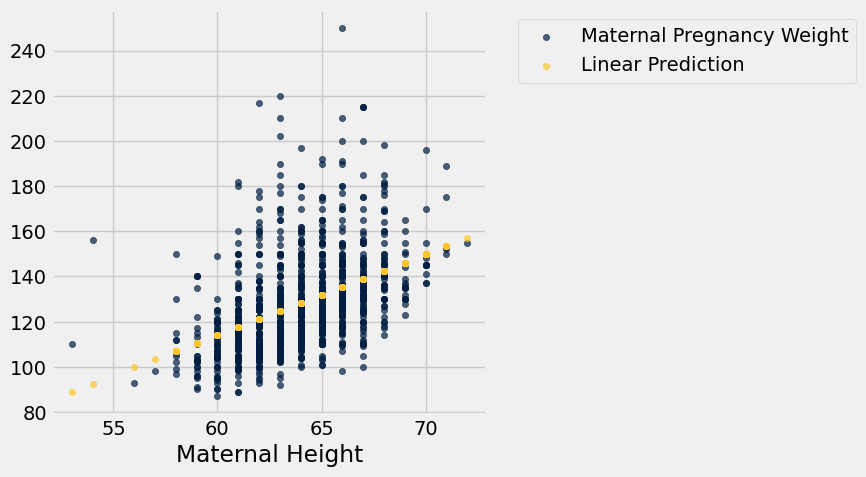

In [73]:
baby_with_predictions = baby.with_column(
    'Linear Prediction', regression_slope * baby.column('Maternal Height') + regression_intercept
)
baby_with_predictions.scatter('Maternal Height')

In [74]:
baby_with_predictions

Maternal Height,Maternal Pregnancy Weight,Linear Prediction
62,100,121.157
64,135,128.302
64,115,128.302
67,125,139.021
62,93,121.157
62,178,121.157
65,140,131.875
62,125,121.157
66,136,135.448
68,120,142.594


In [75]:
100 - 121.157

-21.156999999999996

In [78]:
errors = baby_with_predictions.column('Maternal Pregnancy Weight') - baby_with_predictions.column('Linear Prediction')
baby_with_predictions.with_column('Error', errors)

Maternal Height,Maternal Pregnancy Weight,Linear Prediction,Error
62,100,121.157,-21.1565
64,135,128.302,6.69781
64,115,128.302,-13.3022
67,125,139.021,-14.0207
62,93,121.157,-28.1565
62,178,121.157,56.8435
65,140,131.875,8.12496
62,125,121.157,3.8435
66,136,135.448,0.552114
68,120,142.594,-22.5936


In [81]:
round(sum(errors), 5)  # sum of the errors is 0!
# This is the best line through the data, so just as many points were above as below.

-0.0

In [85]:
mse = np.average(errors ** 2)
mse

348.15630337870471

In [86]:
rmse = np.average(errors ** 2) ** 0.5
rmse

18.658947006160467

---

# Crushed ICE Examples

In [4]:
sons_heights = Table.read_table('data/sons_heights.csv').select('father', 'son')
sons_heights

father,son
78.5,73.2
75.5,73.5
75,71
75,70.5
75,72
74,76.5
74,74
73,71
73,68
73,71


In [10]:
m = slope(sons_heights, 'father', 'son')
b = intercept(sons_heights, 'father', 'son')
predictions = m*sons_heights.column('father') + b
sons_heights = sons_heights.with_column('predicted son height', predictions)
sons_heights

father,son,predicted son height
78.5,73.2,75.1815
75.5,73.5,73.6732
75,71,73.4218
75,70.5,73.4218
75,72,73.4218
74,76.5,72.919
74,74,72.919
73,71,72.4162
73,68,72.4162
73,71,72.4162


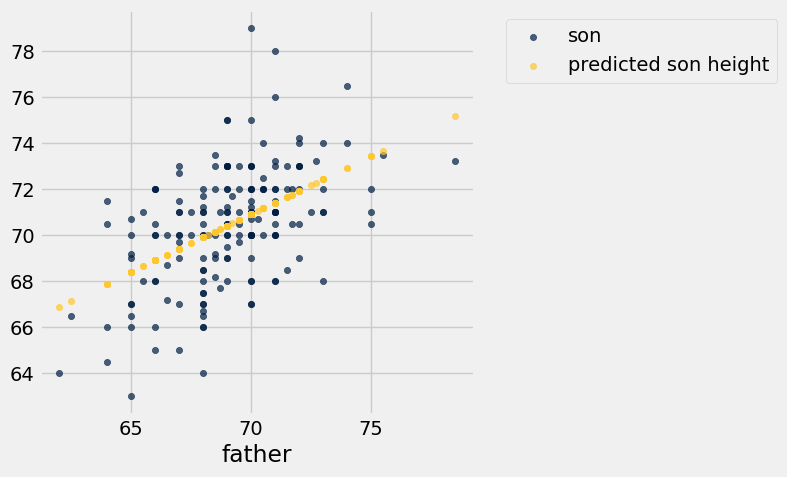

In [11]:
sons_heights.scatter('father')

In [13]:
errors = sons_heights.column('son') - sons_heights.column('predicted son height')
sons_heights.with_column('error', errors)

father,son,predicted son height,error
78.5,73.2,75.1815,-1.98154
75.5,73.5,73.6732,-0.173169
75,71,73.4218,-2.42177
75,70.5,73.4218,-2.92177
75,72,73.4218,-1.42177
74,76.5,72.919,3.58102
74,74,72.919,1.08102
73,71,72.4162,-1.41619
73,68,72.4162,-4.41619
73,71,72.4162,-1.41619


In [15]:
mse = np.mean(errors ** 2)
rmse = mse ** 0.5
rmse

2.2072170474409565

In [16]:
cereal = Table.read_table('data/cereal.csv')
pokemon = Table.read_table('data/pokemon.csv')

In [17]:
cereal

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138
